# Train XLM-R slot-filling model v2 (Ferman Assistant) — RunPod edition

Trains a token-classification model (`xlm-roberta-base`) that extracts **slots**
from a command — the `[slot : value]` spans in `XLMR_dataset_4lang_v2.csv`'s
`annot` column, e.g.

    remind me [date : Friday] at [time : 5 pm]  ->  date=Friday, time=5 pm

Companion to `train_xlmr_intent_v2_runpod.ipynb` — together they give `main.py`
both `intent` and `slots`. Saved in the same folder layout as `xlmr-slot/`, so
the backend picks it up automatically via `SLOT_DIR`/`SLOT_REPO`.

**Languages: English, Arabic, Sorani, Badini.** Arabic previously had zero
slot annotations (0 of 11,097 rows) — this notebook now includes Arabic
because 304 Arabic rows were manually annotated and merged into v2
(see `ar_slot_annotation_draft.txt` for the review record). That's still far
sparser than en/sorani/badini, so Arabic gets the same oversampling boost as
Kurdish below.

**Known limitation**: all 304 annotated Arabic rows are in the `train`
partition — there's no annotated Arabic `validation`/`test` data yet, so the
per-language evaluation table at the end will show 0 test examples for
Arabic. Training will work; there's just no quantitative Arabic slot score
to check yet, only manual spot-checking of real predictions afterward.

This version trains on the same 34-intent, spelling-corrected v2 dataset used
for the intent model, so slot boundaries benefit from the same Badini fixes
(the `سوبەهی` correction, weekday spelling additions, etc.) instead of the
stale pre-fix text.

## RunPod setup (do this once per pod)
1. Deploy a pod from the **RunPod PyTorch template** (any T4/A5000/A100).
2. Open the pod's Jupyter Lab link.
3. Upload `XLMR_dataset_4lang_v2.csv` into the same folder as this notebook.
4. Run all cells top to bottom.
5. Download `xlmr-slot-v2.zip`, or push straight to the Hugging Face Hub
   (cell provided) so `main.py` can pick it up via `SLOT_REPO`.


In [1]:
!pip install -q transformers datasets accelerate seqeval huggingface_hub matplotlib

In [2]:
import random
import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 64                       # matches main.py's inference-time max_length
LANGUAGES = ["en", "ar", "sorani", "badini"]  # ar now has 304 manually annotated rows
EPOCHS = 8
# Kurdish (and now Arabic, at only 304 rows) are under-represented for slots;
# duplicate their TRAIN rows to balance (labels are preserved exactly, so
# duplication is safe for token classification).
OVERSAMPLE_LOWRES = 2                   # 1 = off, 2 = one extra copy, etc.
LOWRES_LANGS = ("sorani", "badini", "ar")

import matplotlib.pyplot as plt
PALETTE = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD"]
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.size": 12, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

print("GPU:", torch.cuda.is_available(), "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

GPU: True - NVIDIA GeForce RTX 4090


## 1. Load the dataset

`XLMR_dataset_4lang_v2.csv` must already be sitting next to this notebook
(uploaded via Jupyter Lab's file browser).

In [3]:
CSV_PATH = "XLMR_dataset_4lang_v2.csv"

df = pd.read_csv(CSV_PATH)
df = df[df["language"].isin(LANGUAGES)].copy()
df = df[df["annot"].notna()].reset_index(drop=True)   # drop rows without annotations
print(df.shape)
print(df["language"].value_counts())
print(df["partition"].value_counts())

(16652, 5)
language
en        11097
sorani     2626
badini     2625
ar          304
Name: count, dtype: int64
partition
train         12186
test           2694
validation     1772
Name: count, dtype: int64


## 2. Parse annotations into BIO tags

Each `annot` looks like `word [slot : value words] word`. We turn it into a list
of tokens and a matching list of BIO tags (`O`, `B-<slot>`, `I-<slot>`) — the
exact label scheme `main.py` expects (`tag[2:]` gives the slot name).

In [4]:
import re

_PAT = re.compile(r"\[([^:\]]+):([^\]]+)\]")

def parse_annot(annot):
    tokens, tags = [], []
    last = 0
    for m in _PAT.finditer(annot):
        for w in annot[last:m.start()].split():
            tokens.append(w); tags.append("O")
        slot = m.group(1).strip()
        for i, w in enumerate(m.group(2).strip().split()):
            tokens.append(w); tags.append(("B-" if i == 0 else "I-") + slot)
        last = m.end()
    for w in annot[last:].split():
        tokens.append(w); tags.append("O")
    return tokens, tags

records = []
for _, r in df.iterrows():
    toks, tags = parse_annot(r["annot"])
    if not toks:
        continue
    records.append({"tokens": toks, "tags": tags,
                    "language": r["language"], "partition": r["partition"]})

# label set: O first, then sorted B-/I- pairs
slot_types = sorted({t[2:] for rec in records for t in rec["tags"] if t != "O"})
labels = ["O"] + [f"{p}-{s}" for s in slot_types for p in ("B", "I")]
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for i, l in enumerate(labels)}
print(len(slot_types), "slot types,", len(labels), "BIO labels")
print("slots:", slot_types)

for rec in records:
    rec["ner_tags"] = [label2id[t] for t in rec["tags"]]

# example
ex = records[0]
print("\nexample:", list(zip(ex["tokens"], ex["tags"]))[:12])

43 slot types, 87 BIO labels
slots: ['alarm_type', 'app_name', 'artist_name', 'business_name', 'business_type', 'cooking_type', 'currency_name', 'date', 'definition_word', 'device_type', 'drink_type', 'email_address', 'email_folder', 'event_name', 'food_type', 'general_frequency', 'house_place', 'ingredient', 'joke_type', 'list_item', 'list_name', 'meal_type', 'media_type', 'movie_name', 'movie_type', 'music_descriptor', 'music_genre', 'news_topic', 'order_type', 'person', 'personal_info', 'place_name', 'relation', 'song_name', 'sport_type', 'time', 'time_zone', 'timeofday', 'transport_agency', 'transport_descriptor', 'transport_name', 'transport_type', 'weather_descriptor']

example: [('wake', 'O'), ('me', 'O'), ('up', 'O'), ('at', 'O'), ('nine', 'B-time'), ('am', 'I-time'), ('on', 'O'), ('friday', 'B-date')]


### Dataset overview

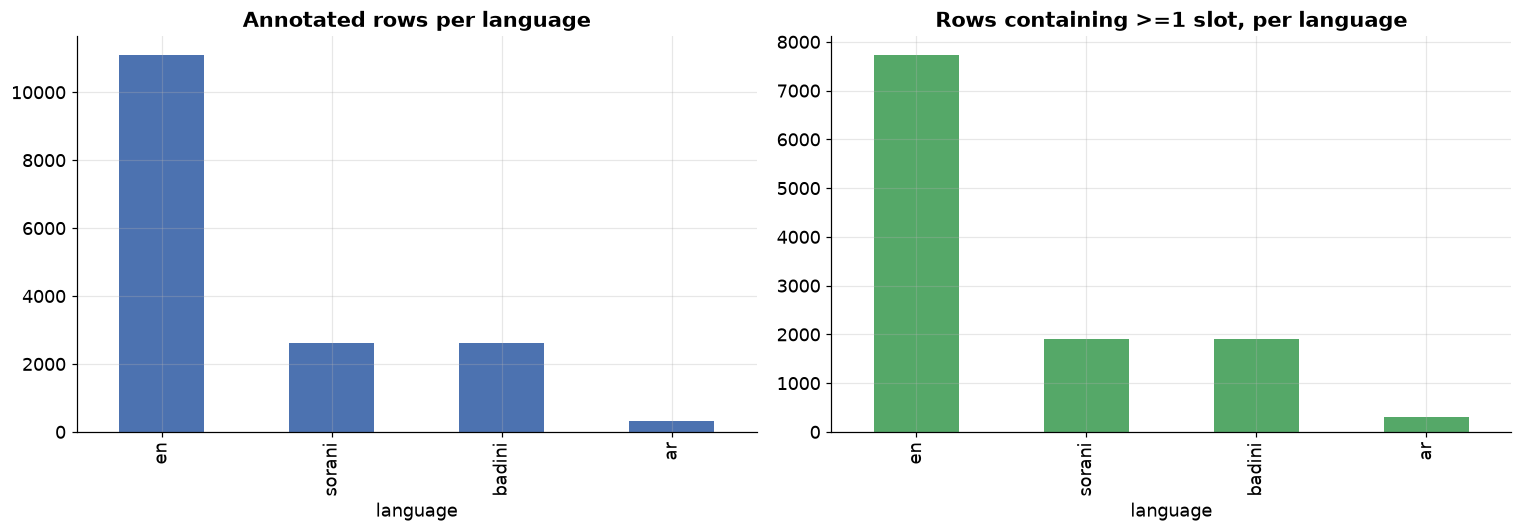

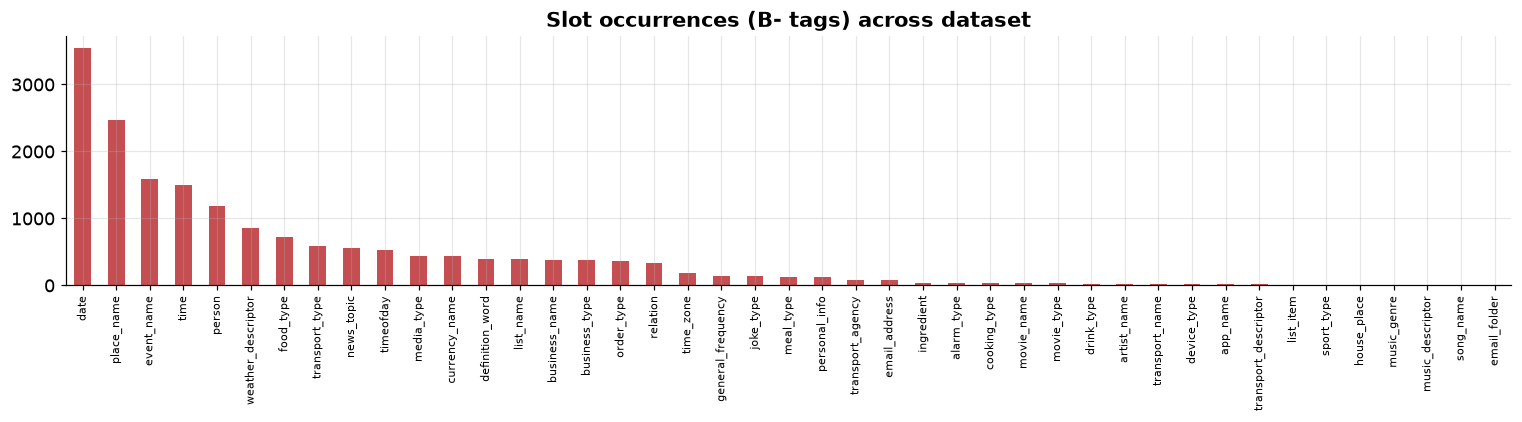

In [5]:
rec_df = pd.DataFrame(records)

# slot-bearing rows per language
has_slot = rec_df["tags"].apply(lambda ts: any(t != "O" for t in ts))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rec_df["language"].value_counts().plot(kind="bar", ax=axes[0], color=PALETTE[0])
axes[0].set_title("Annotated rows per language")
rec_df[has_slot]["language"].value_counts().plot(kind="bar", ax=axes[1], color=PALETTE[1])
axes[1].set_title("Rows containing >=1 slot, per language")
plt.tight_layout(); plt.savefig("slot_chart_overview.png"); plt.show()

# most common slot types
from collections import Counter
slot_counts = Counter(t[2:] for rec in records for t in rec["tags"] if t.startswith("B-"))
sc = pd.Series(dict(slot_counts)).sort_values(ascending=False)
plt.figure(figsize=(14, 4))
sc.plot(kind="bar", color=PALETTE[2])
plt.title("Slot occurrences (B- tags) across dataset")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout(); plt.savefig("slot_chart_distribution.png"); plt.show()

## 3. Build splits (with optional Kurdish oversampling)

In [6]:
from datasets import Dataset, DatasetDict

def split_records(part):
    return [r for r in records if r["partition"] == part]

train_recs = split_records("train")
if OVERSAMPLE_LOWRES > 1:
    extra = [r for r in train_recs if r["language"] in LOWRES_LANGS]
    train_recs = train_recs + extra * (OVERSAMPLE_LOWRES - 1)
    random.shuffle(train_recs)
print("train rows (after oversampling):", len(train_recs))

def to_ds(recs):
    return Dataset.from_dict({
        "tokens": [r["tokens"] for r in recs],
        "ner_tags": [r["ner_tags"] for r in recs],
        "language": [r["language"] for r in recs],
    })

raw = DatasetDict({
    "train": to_ds(train_recs),
    "validation": to_ds(split_records("validation")),
    "test": to_ds(split_records("test")),
})
raw

train rows (after oversampling): 16619


DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags', 'language'],
        num_rows: 16619
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'language'],
        num_rows: 1772
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'language'],
        num_rows: 2694
    })
})

## 4. Tokenize + align labels

Sub-word tokens inherit their word's label on the first piece; continuation
pieces and special tokens get `-100` (ignored by the loss).

In [7]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align(examples):
    tok = tokenizer(examples["tokens"], truncation=True, max_length=MAX_LENGTH,
                    is_split_into_words=True)
    all_labels = []
    for i, tags in enumerate(examples["ner_tags"]):
        word_ids = tok.word_ids(batch_index=i)
        prev, row = None, []
        for wid in word_ids:
            if wid is None:
                row.append(-100)
            elif wid != prev:
                row.append(tags[wid])
            else:
                row.append(-100)
            prev = wid
        all_labels.append(row)
    tok["labels"] = all_labels
    return tok

tokenized = raw.map(tokenize_and_align, batched=True, remove_columns=["tokens", "ner_tags"])

Map:   0%|          | 0/16619 [00:00<?, ? examples/s]

Map:   0%|          | 0/1772 [00:00<?, ? examples/s]

Map:   0%|          | 0/2694 [00:00<?, ? examples/s]

## 5. Model + Trainer

In [8]:
from transformers import (
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from seqeval.metrics import f1_score as seq_f1, precision_score as seq_p, recall_score as seq_r

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=len(labels), id2label=id2label, label2id=label2id,
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

def decode(preds, labels_):
    true, pred = [], []
    for p_row, l_row in zip(preds, labels_):
        t, q = [], []
        for p_i, l_i in zip(p_row, l_row):
            if l_i == -100:
                continue
            t.append(id2label[l_i]); q.append(id2label[p_i])
        true.append(t); pred.append(q)
    return true, pred

def compute_metrics(eval_pred):
    logits, labels_ = eval_pred
    preds = np.argmax(logits, axis=2)
    true, pred = decode(preds, labels_)
    return {
        "precision": seq_p(true, pred),
        "recall": seq_r(true, pred),
        "f1": seq_f1(true, pred),
    }

args = TrainingArguments(
    output_dir="./xlmr-slot-v2-run",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## 6. Train

In [9]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.784664,0.627011,0.527363,0.509888,0.518478
2,0.446389,0.388727,0.692964,0.694816,0.693888
3,0.320005,0.344197,0.712227,0.765901,0.738089
4,0.206633,0.353752,0.698435,0.787280,0.740201
5,0.190634,0.333677,0.728723,0.805452,0.765169
6,0.131614,0.352109,0.720363,0.805452,0.760535
7,0.104601,0.346969,0.746313,0.811331,0.777465
8,0.092019,0.350890,0.750495,0.810262,0.779234


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4160, training_loss=0.39812199698331263, metrics={'train_runtime': 813.8456, 'train_samples_per_second': 163.363, 'train_steps_per_second': 5.112, 'total_flos': 2579301082250118.0, 'train_loss': 0.39812199698331263, 'epoch': 8.0})

### Training curves

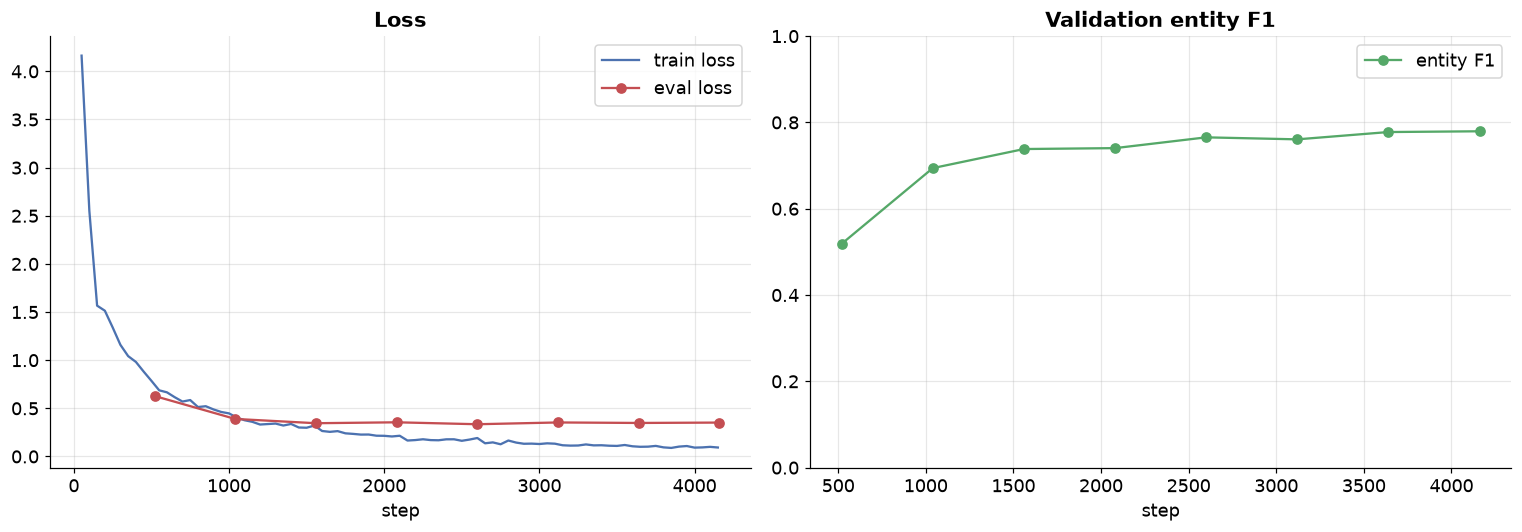

In [10]:
history = trainer.state.log_history
train_pts = [(h["step"], h["loss"]) for h in history if "loss" in h]
eval_pts = [h for h in history if "eval_loss" in h]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if train_pts:
    s, l = zip(*train_pts)
    axes[0].plot(s, l, label="train loss", color=PALETTE[0])
if eval_pts:
    axes[0].plot([h["step"] for h in eval_pts], [h["eval_loss"] for h in eval_pts],
                 marker="o", label="eval loss", color=PALETTE[2])
axes[0].set_title("Loss"); axes[0].set_xlabel("step"); axes[0].legend()
if eval_pts:
    axes[1].plot([h["step"] for h in eval_pts], [h["eval_f1"] for h in eval_pts],
                 marker="o", label="entity F1", color=PALETTE[1])
axes[1].set_ylim(0, 1); axes[1].set_title("Validation entity F1"); axes[1].set_xlabel("step"); axes[1].legend()
plt.tight_layout(); plt.savefig("slot_chart_training_curves.png"); plt.show()

## 7. Evaluate on the held-out test set

In [11]:
from seqeval.metrics import classification_report

test_pred = trainer.predict(tokenized["test"])
preds = np.argmax(test_pred.predictions, axis=2)
true, pred = decode(preds, test_pred.label_ids)

print("test entity precision:", seq_p(true, pred))
print("test entity recall:   ", seq_r(true, pred))
print("test entity f1:       ", seq_f1(true, pred))
print()
print(classification_report(true, pred))

test entity precision: 0.7433118862174061
test entity recall:    0.79644412191582
test entity f1:        0.7689612891925031

                      precision    recall  f1-score   support

          alarm_type       0.00      0.00      0.00         5
            app_name       0.00      0.00      0.00         2
         artist_name       0.00      0.00      0.00         1
       business_name       0.67      0.62      0.65        53
       business_type       0.65      0.70      0.67        50
        cooking_type       0.00      0.00      0.00        12
       currency_name       0.85      0.87      0.86        90
                date       0.83      0.91      0.86       486
     definition_word       0.74      0.84      0.79        73
         device_type       0.00      0.00      0.00         1
          drink_type       0.00      0.00      0.00         1
       email_address       1.00      1.00      1.00        15
          event_name       0.72      0.77      0.74       303
      

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Performance breakdown: per-slot and per-language

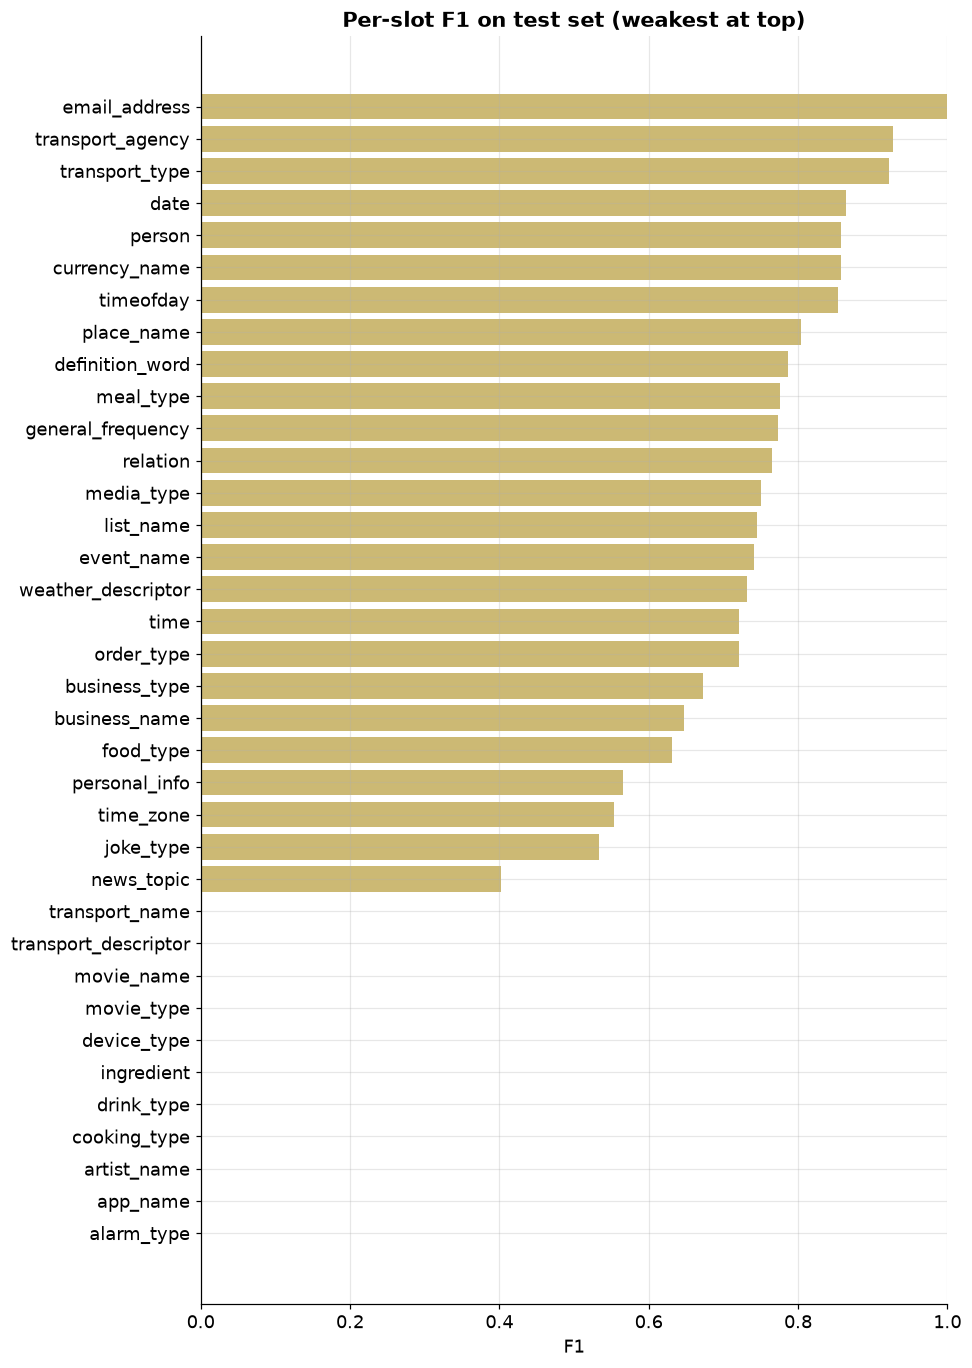

In [12]:
# --- per-slot F1 (weakest at top) ---
rep = classification_report(true, pred, output_dict=True)
per_slot = {k: v["f1-score"] for k, v in rep.items()
            if k not in ("micro avg", "macro avg", "weighted avg")}
ps = pd.Series(per_slot).sort_values()
plt.figure(figsize=(9, max(4, 0.35 * len(ps))))
plt.barh(ps.index, ps.values, color=PALETTE[4])
plt.xlabel("F1"); plt.xlim(0, 1); plt.title("Per-slot F1 on test set (weakest at top)")
plt.tight_layout(); plt.savefig("slot_chart_per_slot_f1.png"); plt.show()

  language  precision    recall        f1     n
0       en   0.790655  0.844423  0.816655  1954
1   sorani   0.619792  0.668539  0.643243   370
2   badini   0.598446  0.648876  0.622642   370


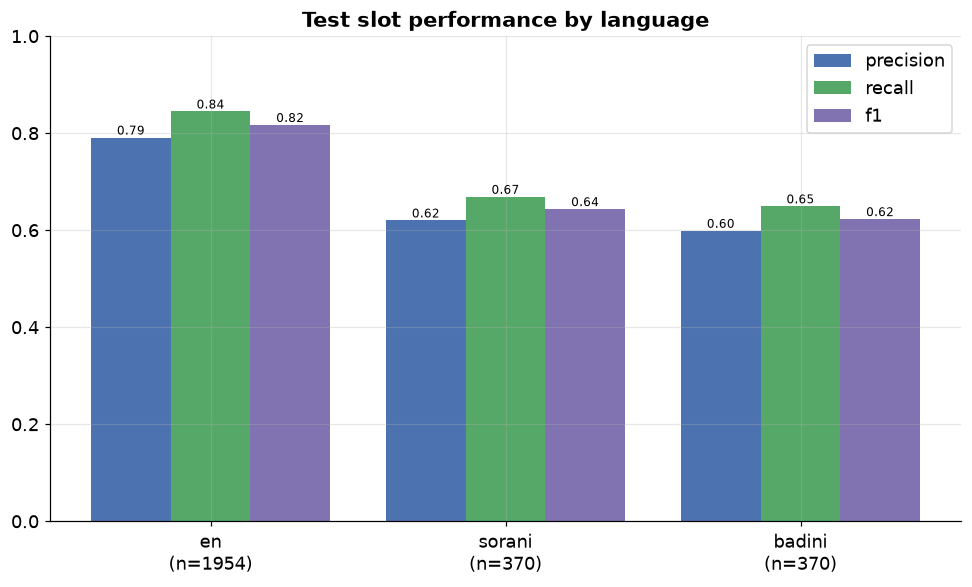

In [13]:
# --- per-language entity F1 ---
test_langs = tokenized["test"]["language"]
rows = []
for lang in LANGUAGES:
    idx = [i for i, l in enumerate(test_langs) if l == lang]
    if not idx:
        continue
    t = [true[i] for i in idx]; p = [pred[i] for i in idx]
    rows.append({"language": lang, "precision": seq_p(t, p),
                 "recall": seq_r(t, p), "f1": seq_f1(t, p), "n": len(idx)})
lang_df = pd.DataFrame(rows)
print(lang_df)

xs = np.arange(len(lang_df)); w = 0.27
fig, ax = plt.subplots(figsize=(9, 5.5))
for k, (col, color) in enumerate([("precision", PALETTE[0]), ("recall", PALETTE[1]), ("f1", PALETTE[3])]):
    bars = ax.bar(xs + (k - 1) * w, lang_df[col], w, label=col, color=color)
    for b in bars:
        ax.annotate(f"{b.get_height():.2f}", (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", fontsize=8)
ax.set_xticks(xs)
ax.set_xticklabels([f"{l}\n(n={int(n)})" for l, n in zip(lang_df["language"], lang_df["n"])])
ax.set_ylim(0, 1); ax.set_title("Test slot performance by language"); ax.legend()
plt.tight_layout(); plt.savefig("slot_chart_language_performance.png"); plt.show()

## 8. Save the model

Same layout as the intent model (`config.json` with `id2label`/`label2id`,
`model.safetensors`, tokenizer). `main.py` loads it as the slot model with no
code changes.

In [14]:
SAVE_DIR = "xlmr-slot-v2"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print("Saved to", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to xlmr-slot-v2


## 9. Get the model out of the pod

**A. Zip + download via Jupyter Lab's file browser.**

In [15]:
!zip -rq xlmr-slot-v2.zip xlmr-slot-v2
print("Ready: xlmr-slot-v2.zip (download it from the Jupyter file browser)")

Ready: xlmr-slot-v2.zip (download it from the Jupyter file browser)


**B. Push straight to the Hugging Face Hub (recommended)** — this is what
`main.py` reads via the `SLOT_REPO` env var. Set `HF_TOKEN` and `HF_REPO_ID`
below, then run.